In [26]:
path_predictions = "/private/home/francoisporcher/detrex/experiments/train_dinov3_detector/dino_vitdet_dinov3_base_12ep_512/coco_instances_results.json"
path_gt = "/private/home/francoisporcher/data/waymococo_f0/annotations/instances_val2020_target_only.json"
path_validation_images = "/private/home/francoisporcher/data/waymococo_f0/val2020"

In [ ]:
from pycocotools.coco import COCO

coco_gt = COCO(path_gt)
coco_dt = coco_gt.loadRes(path_predictions)

loading annotations into memory...


Done (t=5.39s)
creating index...
index created!
Loading and preparing results...
DONE (t=226.67s)
creating index...
index created!


In [32]:
img_id

40

In [33]:
gt_anns

[{'id': 517,
  'image_id': 40,
  'category_id': 1,
  'segmentation': None,
  'area': 1008.434186,
  'bbox': [624.326715, 640.43226, 49.89561, 20.21088],
  'iscrowd': 0,
  'track_id': '037a0ea9-5597-4a75-9375-4fc0dc1e7c94',
  'det_difficult': 0,
  'track_difficult': 0,
  'frame_type': 'target',
  'subvideo_idx': 0,
  'local_frame_idx': 8,
  'global_frame_idx': 8},
 {'id': 518,
  'image_id': 40,
  'category_id': 1,
  'segmentation': None,
  'area': 524.960201,
  'bbox': [280.741755, 630.32682, 29.68473, 17.68452],
  'iscrowd': 0,
  'track_id': '12f82ab7-17cd-4436-bc30-7ffaecdef933',
  'det_difficult': 2,
  'track_difficult': 2,
  'frame_type': 'target',
  'subvideo_idx': 0,
  'local_frame_idx': 8,
  'global_frame_idx': 8},
 {'id': 519,
  'image_id': 40,
  'category_id': 1,
  'segmentation': None,
  'area': 149.589723,
  'bbox': [445.586745, 629.379435, 15.78975, 9.47385],
  'iscrowd': 0,
  'track_id': '1a180718-ec58-4358-b5ff-304d191118a0',
  'det_difficult': 2,
  'track_difficult': 2,
 

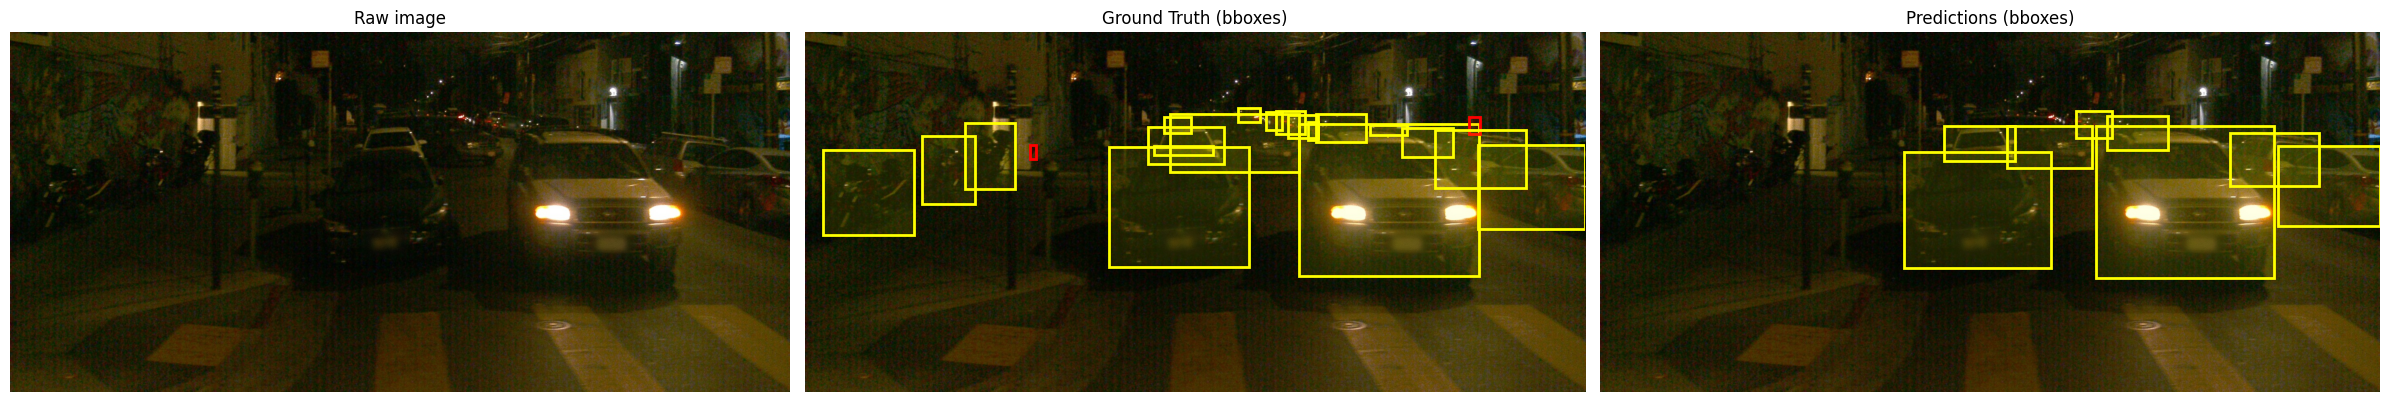

In [55]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
from matplotlib.patches import Rectangle
import random

list_of_img_ids = coco_gt.getImgIds()
# get random id
img_id = random.choice(list_of_img_ids)

# Load image
img_info = coco_gt.loadImgs(img_id)[0]
img_file_path = f"{path_validation_images}/{img_info['file_name']}"

img = cv2.imread(img_file_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load GT + predictions
gt_anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
dt_anns = coco_dt.loadAnns(coco_dt.getAnnIds(imgIds=img_id))

def draw_bboxes(ax, anns, color="lime", show_labels=False, score_thr=None):
    """
    Draw COCO-format bboxes on a matplotlib axis.
    anns: list of dicts with 'bbox' in [x, y, w, h]
    score_thr: if not None, only draw preds with ann['score'] >= score_thr
    """

    # >>> Added: per-class colors <<<
    color_map = {
        1: "yellow",      # TYPE_VEHICLE
        2: "red",         # TYPE_PEDESTRIAN
        3: "cyan",        # TYPE_CYCLIST
    }

    for ann in anns:
        if score_thr is not None and ann.get("score", 1.0) < score_thr:
            continue

        x, y, w, h = ann["bbox"]

        # pick color based on category, fallback to given `color`
        c = color_map.get(ann.get("category_id", -1), color)

        # >>> Added translucent filled box <<<
        ax.add_patch(
            Rectangle(
                (x, y), w, h,
                fill=True,
                facecolor=c,
                alpha=0.1,         # transparency
                edgecolor=None
            )
        )

        # original bounding box outline
        rect = Rectangle((x, y), w, h, fill=False, linewidth=2, edgecolor=c)
        ax.add_patch(rect)

        if show_labels:
            cat_id = ann.get("category_id", -1)
            label = str(cat_id)
            if "score" in ann:
                label += f" {ann['score']:.2f}"
            ax.text(x, y, label, color=c, fontsize=8, va="top",
                    bbox=dict(facecolor="black", alpha=0.8, pad=1, edgecolor="none"))

# ---- 3-panel plot ----
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 1. Raw image
axes[0].imshow(img)
axes[0].set_title("Raw image")
axes[0].axis("off")

# 2. Ground Truth
axes[1].imshow(img)
axes[1].set_title("Ground Truth (bboxes)")
axes[1].axis("off")
draw_bboxes(axes[1], gt_anns, color="deepskyblue")

# 3. Predictions
axes[2].imshow(img)
axes[2].set_title("Predictions (bboxes)")
axes[2].axis("off")
draw_bboxes(axes[2], dt_anns, color="lime", score_thr=0.5)

plt.tight_layout()
plt.show()


loading annotations into memory...


Done (t=8.42s)
creating index...
index created!
Image ID from predictions: 114873
Number of predictions: 300
Number of GT annotations: 1


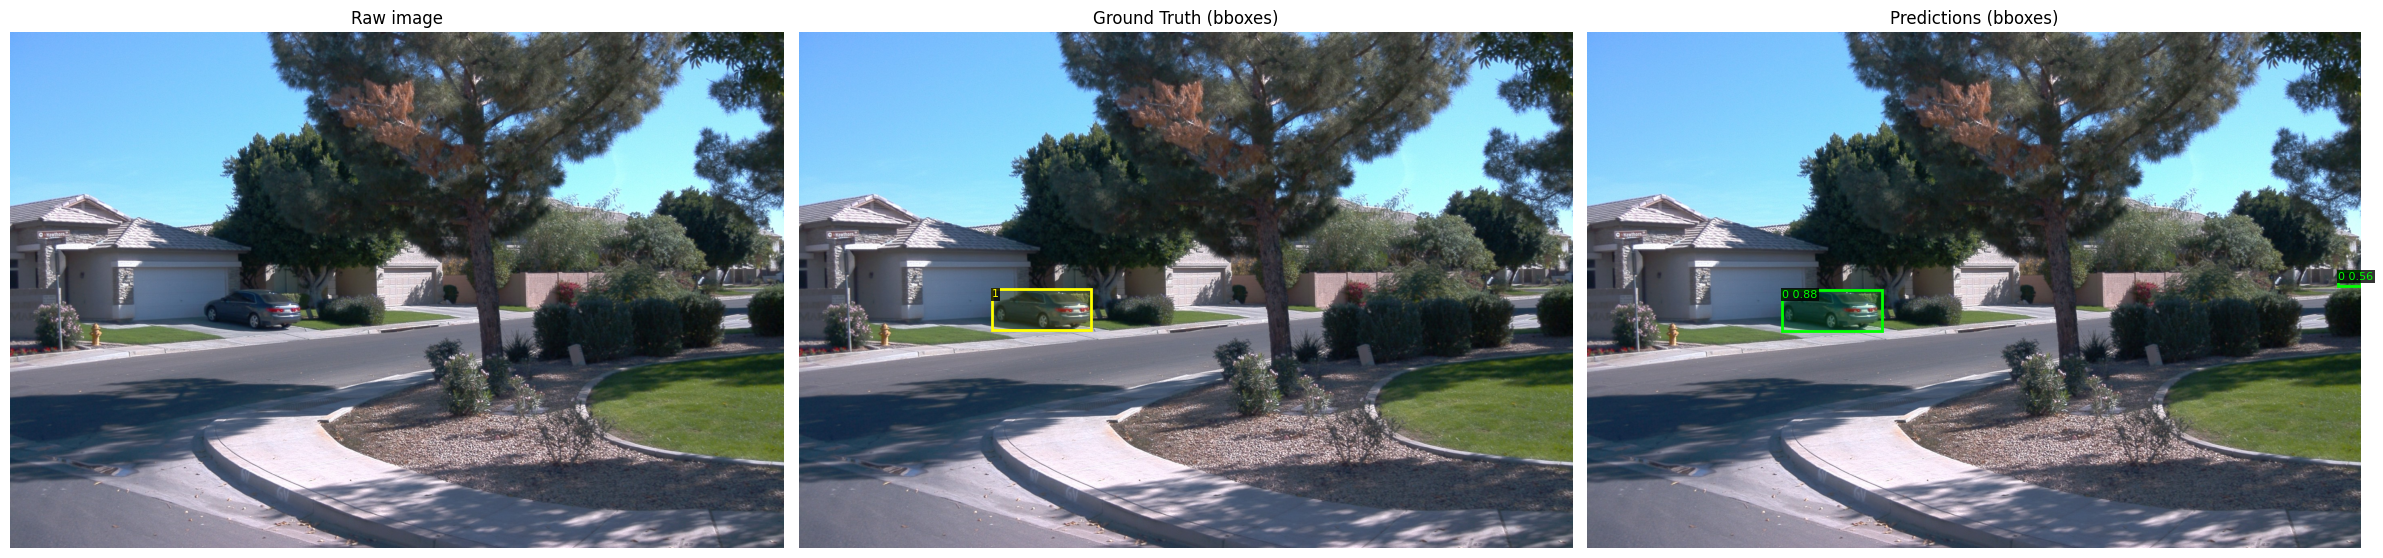

In [5]:
import json
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
from matplotlib.patches import Rectangle
img_id = 114873
# Paths
path_predictions = "/private/home/francoisporcher/FutureLatents2/predictions_coco_format.json"
path_gt = "/private/home/francoisporcher/data/waymococo_f0/annotations/instances_val2020_target_only.json"
path_validation_images = "/private/home/francoisporcher/data/waymococo_f0/val2020"

# Load ground truth
coco_gt = COCO(path_gt)

# Load predictions directly as JSON
with open(path_predictions, 'r') as f:
    predictions_list = json.load(f)

# Get the image_id from the predictions file (assuming all predictions are for the same image)
img_id = predictions_list[0]['image_id']

print(f"Image ID from predictions: {img_id}")
print(f"Number of predictions: {len(predictions_list)}")

# Load image
img_info = coco_gt.loadImgs(img_id)[0]
img_file_path = f"{path_validation_images}/{img_info['file_name']}"
img = cv2.imread(img_file_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load GT annotations
gt_anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))

# Get predictions for this image (all predictions in the file)
dt_anns = predictions_list

print(f"Number of GT annotations: {len(gt_anns)}")

def draw_bboxes(ax, anns, color="lime", show_labels=False, score_thr=None):
    """
    Draw COCO-format bboxes on a matplotlib axis.
    anns: list of dicts with 'bbox' in [x, y, w, h]
    score_thr: if not None, only draw preds with ann['score'] >= score_thr
    """
    # Per-class colors
    color_map = {
        1: "yellow",      # TYPE_VEHICLE
        2: "red",         # TYPE_PEDESTRIAN
        3: "cyan",        # TYPE_CYCLIST
    }
    
    for ann in anns:
        if score_thr is not None and ann.get("score", 1.0) < score_thr:
            continue
        
        x, y, w, h = ann["bbox"]
        
        # Pick color based on category, fallback to given `color`
        c = color_map.get(ann.get("category_id", -1), color)
        
        # Translucent filled box
        ax.add_patch(
            Rectangle(
                (x, y), w, h,
                fill=True,
                facecolor=c,
                alpha=0.1,
                edgecolor=None
            )
        )
        
        # Original bounding box outline
        rect = Rectangle((x, y), w, h, fill=False, linewidth=2, edgecolor=c)
        ax.add_patch(rect)
        
        if show_labels:
            cat_id = ann.get("category_id", -1)
            label = str(cat_id)
            if "score" in ann:
                label += f" {ann['score']:.2f}"
            ax.text(x, y, label, color=c, fontsize=8, va="top",
                   bbox=dict(facecolor="black", alpha=0.8, pad=1, edgecolor="none"))

# ---- 3-panel plot ----
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 1. Raw image
axes[0].imshow(img)
axes[0].set_title("Raw image")
axes[0].axis("off")

# 2. Ground Truth
axes[1].imshow(img)
axes[1].set_title("Ground Truth (bboxes)")
axes[1].axis("off")
draw_bboxes(axes[1], gt_anns, color="deepskyblue", show_labels=True)

# 3. Predictions
axes[2].imshow(img)
axes[2].set_title("Predictions (bboxes)")
axes[2].axis("off")
draw_bboxes(axes[2], dt_anns, color="lime", score_thr=0.5, show_labels=True)

plt.tight_layout()
plt.show()